# 01. Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

import joblib

# 02. Importando el dataset

In [2]:
url = 'https://raw.githubusercontent.com/ezeperezds/Anemia-Prediction-System/refs/heads/develop/data/raw/anemia.csv'

data = pd.read_csv(url)

In [3]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
760,1,16.6,18.8,28.1,70.9,0
347,1,13.1,25.6,28.4,77.5,1
94,1,11.6,24.3,29.1,85.7,1
1168,0,11.7,24.4,31.5,99.8,1
442,1,14.8,16.3,27.8,76.4,0
487,0,14.7,28.9,31.0,69.8,0
78,1,10.7,19.0,32.2,77.1,1
486,0,13.4,25.2,30.2,95.9,0
1086,0,13.3,19.1,30.9,97.9,0
404,1,16.7,16.5,30.5,94.5,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


# 3. Feature Engineering

## Hemoglobina baja según genero

Si el paciente es hombre y su hemoglobina es menor a 13, tiene la hemoglobina baja

Si el paciente es mujer y su hemoglobina es menor a 12, tiene la hemoglobina baja

In [5]:
anemia_hb = []

for index, row in data.iterrows():
  if row['Hemoglobin'] < 13 and row['Gender'] == 0:
    anemia_hb.append(1)
  elif row['Hemoglobin'] < 12 and row['Gender'] == 1:
    anemia_hb.append(1)
  else:
    anemia_hb.append(0)

In [6]:
data['Low_Hb'] = anemia_hb

In [7]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Low_Hb
760,1,16.6,18.8,28.1,70.9,0,0
347,1,13.1,25.6,28.4,77.5,1,0
94,1,11.6,24.3,29.1,85.7,1,1
1168,0,11.7,24.4,31.5,99.8,1,1
442,1,14.8,16.3,27.8,76.4,0,0
487,0,14.7,28.9,31.0,69.8,0,0
78,1,10.7,19.0,32.2,77.1,1,1
486,0,13.4,25.2,30.2,95.9,0,0
1086,0,13.3,19.1,30.9,97.9,0,0
404,1,16.7,16.5,30.5,94.5,0,0


## Clasificación del MCV

Si MCV es menor a 80 -> Microcítica

Si MCV esta entre 80 - 100 -> Normocítica (Normal)

Si MCV es mayor a 100 -> Macrocítica

In [8]:
mcv_categoria = []

for index, row in data.iterrows():
  if (row['MCV'] < 80):
    mcv_categoria.append('Micro')
  elif ((row['MCV'] >= 80) & (row['MCV']<=100)):
    mcv_categoria.append('Normal')
  else:
    mcv_categoria.append('Macro')

In [9]:
data['MCV_Cat'] = mcv_categoria

In [10]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Low_Hb,MCV_Cat
760,1,16.6,18.8,28.1,70.9,0,0,Micro
347,1,13.1,25.6,28.4,77.5,1,0,Micro
94,1,11.6,24.3,29.1,85.7,1,1,Normal
1168,0,11.7,24.4,31.5,99.8,1,1,Normal
442,1,14.8,16.3,27.8,76.4,0,0,Micro
487,0,14.7,28.9,31.0,69.8,0,0,Micro
78,1,10.7,19.0,32.2,77.1,1,1,Micro
486,0,13.4,25.2,30.2,95.9,0,0,Normal
1086,0,13.3,19.1,30.9,97.9,0,0,Normal
404,1,16.7,16.5,30.5,94.5,0,0,Normal


## Relación entre Hemoglobina y MCV

In [11]:
data['HB_MCV_ratio'] = (data['Hemoglobin'] / data['MCV']).round(2)

In [12]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Low_Hb,MCV_Cat,HB_MCV_ratio
760,1,16.6,18.8,28.1,70.9,0,0,Micro,0.23
347,1,13.1,25.6,28.4,77.5,1,0,Micro,0.17
94,1,11.6,24.3,29.1,85.7,1,1,Normal,0.14
1168,0,11.7,24.4,31.5,99.8,1,1,Normal,0.12
442,1,14.8,16.3,27.8,76.4,0,0,Micro,0.19
487,0,14.7,28.9,31.0,69.8,0,0,Micro,0.21
78,1,10.7,19.0,32.2,77.1,1,1,Micro,0.14
486,0,13.4,25.2,30.2,95.9,0,0,Normal,0.14
1086,0,13.3,19.1,30.9,97.9,0,0,Normal,0.14
404,1,16.7,16.5,30.5,94.5,0,0,Normal,0.18


## Clasificación del MCHC

Si MCHC es menor a 32 -> Bajo

Si MCHC esta entre 32 y 36 -> Normal

Si MCHC es mayor a 36 -> Alto

In [13]:
mchc_cat = []

for index, row in data.iterrows():
  if (row['MCHC']) < 32:
    mchc_cat.append('Bajo')
  elif ((row['MCHC'] >= 32) & (row['MCHC'] <= 36)):
    mchc_cat.append('Normal')
  else:
    mchc_cat.append('Alto')

In [14]:
data['MCHC_Cat'] = mchc_cat

In [15]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Low_Hb,MCV_Cat,HB_MCV_ratio,MCHC_Cat
760,1,16.6,18.8,28.1,70.9,0,0,Micro,0.23,Bajo
347,1,13.1,25.6,28.4,77.5,1,0,Micro,0.17,Bajo
94,1,11.6,24.3,29.1,85.7,1,1,Normal,0.14,Bajo
1168,0,11.7,24.4,31.5,99.8,1,1,Normal,0.12,Bajo
442,1,14.8,16.3,27.8,76.4,0,0,Micro,0.19,Bajo
487,0,14.7,28.9,31.0,69.8,0,0,Micro,0.21,Bajo
78,1,10.7,19.0,32.2,77.1,1,1,Micro,0.14,Normal
486,0,13.4,25.2,30.2,95.9,0,0,Normal,0.14,Bajo
1086,0,13.3,19.1,30.9,97.9,0,0,Normal,0.14,Bajo
404,1,16.7,16.5,30.5,94.5,0,0,Normal,0.18,Bajo


## Clasificación del MCH

Si MCH es menor a 27 -> Bajo

Si MCH esta entre 27 y 33 -> Normal

Si MCH es mayor a 33 -> Alto

In [16]:
mch_cat = []

for index, row in data.iterrows():
  if (row['MCH']) < 27:
    mch_cat.append('Bajo')
  elif ((row['MCH'] >= 27) & (row['MCH'] <= 33)):
    mch_cat.append('Normal')
  else:
    mch_cat.append('Alto')

In [17]:
data['MCH_Cat'] = mch_cat

In [18]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Low_Hb,MCV_Cat,HB_MCV_ratio,MCHC_Cat,MCH_Cat
760,1,16.6,18.8,28.1,70.9,0,0,Micro,0.23,Bajo,Bajo
347,1,13.1,25.6,28.4,77.5,1,0,Micro,0.17,Bajo,Bajo
94,1,11.6,24.3,29.1,85.7,1,1,Normal,0.14,Bajo,Bajo
1168,0,11.7,24.4,31.5,99.8,1,1,Normal,0.12,Bajo,Bajo
442,1,14.8,16.3,27.8,76.4,0,0,Micro,0.19,Bajo,Bajo
487,0,14.7,28.9,31.0,69.8,0,0,Micro,0.21,Bajo,Normal
78,1,10.7,19.0,32.2,77.1,1,1,Micro,0.14,Normal,Bajo
486,0,13.4,25.2,30.2,95.9,0,0,Normal,0.14,Bajo,Bajo
1086,0,13.3,19.1,30.9,97.9,0,0,Normal,0.14,Bajo,Bajo
404,1,16.7,16.5,30.5,94.5,0,0,Normal,0.18,Bajo,Bajo


## Indicador de microcitosis

In [19]:
data['Microcitosis'] = np.where(data['MCV'] < 80, 1, 0)

In [20]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Low_Hb,MCV_Cat,HB_MCV_ratio,MCHC_Cat,MCH_Cat,Microcitosis
760,1,16.6,18.8,28.1,70.9,0,0,Micro,0.23,Bajo,Bajo,1
347,1,13.1,25.6,28.4,77.5,1,0,Micro,0.17,Bajo,Bajo,1
94,1,11.6,24.3,29.1,85.7,1,1,Normal,0.14,Bajo,Bajo,0
1168,0,11.7,24.4,31.5,99.8,1,1,Normal,0.12,Bajo,Bajo,0
442,1,14.8,16.3,27.8,76.4,0,0,Micro,0.19,Bajo,Bajo,1
487,0,14.7,28.9,31.0,69.8,0,0,Micro,0.21,Bajo,Normal,1
78,1,10.7,19.0,32.2,77.1,1,1,Micro,0.14,Normal,Bajo,1
486,0,13.4,25.2,30.2,95.9,0,0,Normal,0.14,Bajo,Bajo,0
1086,0,13.3,19.1,30.9,97.9,0,0,Normal,0.14,Bajo,Bajo,0
404,1,16.7,16.5,30.5,94.5,0,0,Normal,0.18,Bajo,Bajo,0


## Indicador de hipocromía

In [21]:
data['Hipocromía'] = np.where(data['MCHC'] < 32, 1, 0)

In [22]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Low_Hb,MCV_Cat,HB_MCV_ratio,MCHC_Cat,MCH_Cat,Microcitosis,Hipocromía
760,1,16.6,18.8,28.1,70.9,0,0,Micro,0.23,Bajo,Bajo,1,1
347,1,13.1,25.6,28.4,77.5,1,0,Micro,0.17,Bajo,Bajo,1,1
94,1,11.6,24.3,29.1,85.7,1,1,Normal,0.14,Bajo,Bajo,0,1
1168,0,11.7,24.4,31.5,99.8,1,1,Normal,0.12,Bajo,Bajo,0,1
442,1,14.8,16.3,27.8,76.4,0,0,Micro,0.19,Bajo,Bajo,1,1
487,0,14.7,28.9,31.0,69.8,0,0,Micro,0.21,Bajo,Normal,1,1
78,1,10.7,19.0,32.2,77.1,1,1,Micro,0.14,Normal,Bajo,1,0
486,0,13.4,25.2,30.2,95.9,0,0,Normal,0.14,Bajo,Bajo,0,1
1086,0,13.3,19.1,30.9,97.9,0,0,Normal,0.14,Bajo,Bajo,0,1
404,1,16.7,16.5,30.5,94.5,0,0,Normal,0.18,Bajo,Bajo,0,1


## Score hematológico simple

In [23]:
data['Score'] = data['Low_Hb'] + (
    (data['MCHC_Cat'] == 'Bajo').astype(int) +
    (data['MCH_Cat'] == 'Bajo').astype(int) +
    (data['MCV_Cat'] == 'Micro').astype(int)
)

In [24]:
data.sample(10, random_state=82)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Low_Hb,MCV_Cat,HB_MCV_ratio,MCHC_Cat,MCH_Cat,Microcitosis,Hipocromía,Score
760,1,16.6,18.8,28.1,70.9,0,0,Micro,0.23,Bajo,Bajo,1,1,3
347,1,13.1,25.6,28.4,77.5,1,0,Micro,0.17,Bajo,Bajo,1,1,3
94,1,11.6,24.3,29.1,85.7,1,1,Normal,0.14,Bajo,Bajo,0,1,3
1168,0,11.7,24.4,31.5,99.8,1,1,Normal,0.12,Bajo,Bajo,0,1,3
442,1,14.8,16.3,27.8,76.4,0,0,Micro,0.19,Bajo,Bajo,1,1,3
487,0,14.7,28.9,31.0,69.8,0,0,Micro,0.21,Bajo,Normal,1,1,2
78,1,10.7,19.0,32.2,77.1,1,1,Micro,0.14,Normal,Bajo,1,0,3
486,0,13.4,25.2,30.2,95.9,0,0,Normal,0.14,Bajo,Bajo,0,1,2
1086,0,13.3,19.1,30.9,97.9,0,0,Normal,0.14,Bajo,Bajo,0,1,2
404,1,16.7,16.5,30.5,94.5,0,0,Normal,0.18,Bajo,Bajo,0,1,2


# 4. Split

In [25]:
# Segmentación de variable explicativas y variable objetivo
X = data.drop(columns='Result')
y = data['Result']

In [26]:
X, X_test, y, y_test = train_test_split(X, y, stratify=y, test_size=0.15, random_state=82)

In [27]:
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.1765, random_state=82)

# 5. Encoding

In [28]:
categorical_features = ['MCV_Cat', 'MCHC_Cat', 'MCH_Cat']

numeric_features = ['Gender', 'Hemoglobin', 'MCH',
                      'MCHC', 'MCV', 'Low_Hb',
                      'HB_MCV_ratio','Microcitosis', 'Hipocromía', 'Score'
                      ]

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop='first', sparse_output=False), categorical_features)
        ]
    )

In [30]:
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

In [31]:
# obtenemos los nombres de las columnas
final_cols = (preprocessor.get_feature_names_out().tolist())

In [32]:
final_cols = [
    col.replace('num__', '').replace('cat__', '')
    for col in final_cols
]

In [33]:
# creamos un dataframe para visualizar los datos de entrenamiento
X_train_df = pd.DataFrame(
    X_train,
    columns=final_cols
)

In [34]:
X_train_df

,Gender,Hemoglobin,MCH,MCHC,MCV,Low_Hb,HB_MCV_ratio,Microcitosis,Hipocromía,Score,MCV_Cat_Micro,MCV_Cat_Normal,MCHC_Cat_Normal,MCH_Cat_Normal
0,-1.063438,-1.387327,-0.884147,-0.733130,0.845910,1.417424,-1.641290,-0.723192,0.430075,0.783577,0.0,1.0,0.0,0.0
1,-1.063438,1.686471,-1.115811,-1.160359,1.083049,-0.705505,0.670016,-0.723192,0.430075,-0.372577,0.0,1.0,0.0,0.0
2,-1.063438,1.232960,0.660285,-1.373974,-1.391448,-0.705505,1.990763,1.382759,0.430075,0.783577,1.0,0.0,0.0,0.0
3,0.940346,-0.480305,-0.703963,-1.729998,0.381942,-0.705505,-0.650730,-0.723192,0.430075,-0.372577,0.0,1.0,0.0,0.0
4,-1.063438,0.930619,-1.424698,1.403015,0.381942,-0.705505,0.339830,-0.723192,-2.325178,-1.528732,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,0.940346,0.981009,0.428620,-0.946745,-1.226481,-0.705505,1.660576,1.382759,0.430075,0.783577,1.0,0.0,0.0,0.0
989,0.940346,-0.681865,-1.012849,0.690967,-0.979031,-0.705505,0.009643,1.382759,0.430075,0.783577,1.0,0.0,0.0,0.0
990,-1.063438,0.930619,-1.167292,0.121328,0.814979,-0.705505,0.009643,-0.723192,0.430075,-0.372577,0.0,1.0,0.0,0.0
991,-1.063438,-1.387327,-0.008969,0.192533,-0.432580,1.417424,-0.980917,-0.723192,0.430075,0.783577,0.0,1.0,0.0,0.0


# 6. VIF y Multicolinealidad

## Correlación

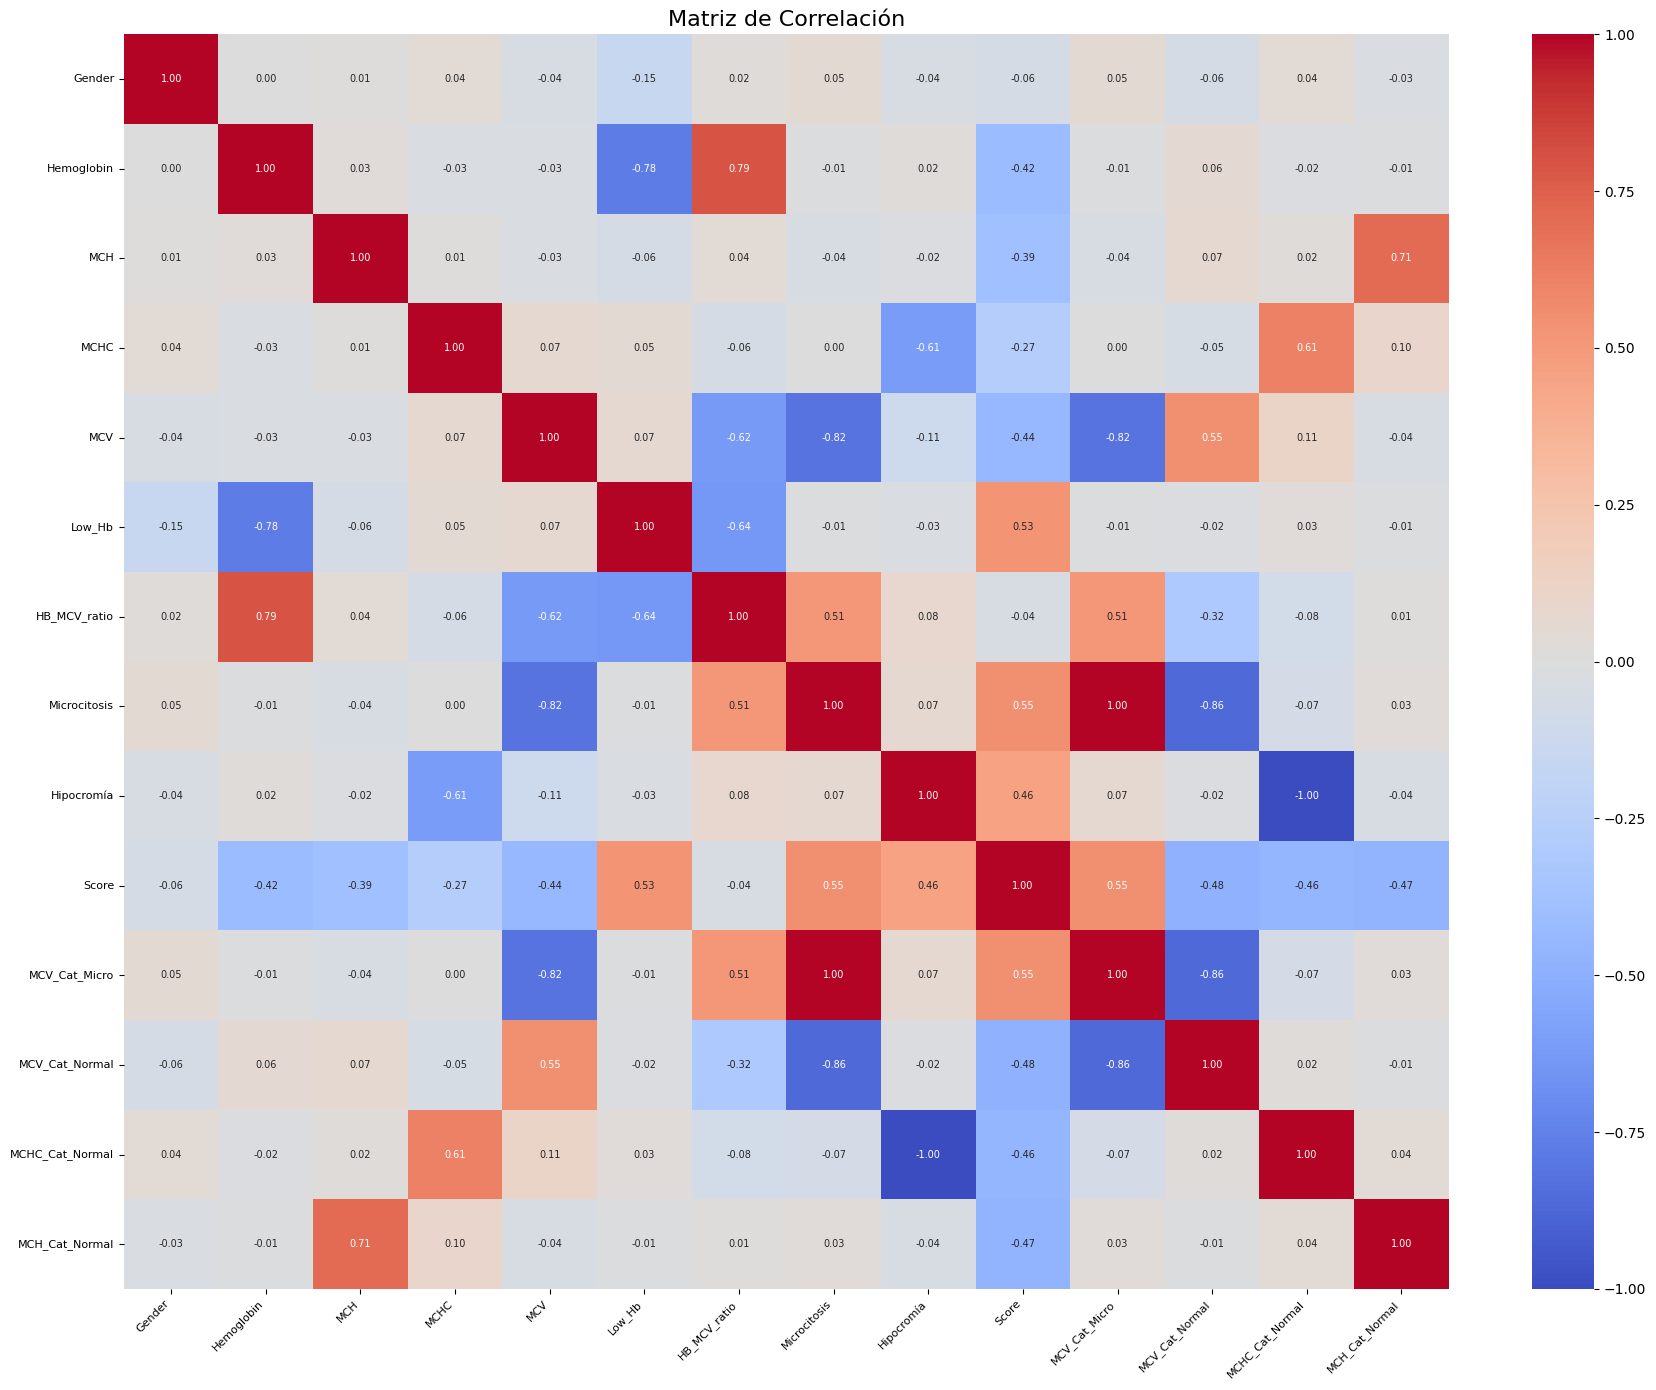

In [35]:
# Analisis de correlación y multicolinearidad

corr = X_train_df.corr().round(2)

plt.figure(figsize=(18, 14))  # definimos el tamaño de figura
sns.heatmap(corr,
            annot=True,         # mostramos los valores de correlación dentro de cada celda
            fmt=".2f",
            cmap='coolwarm',    # paleta de colores
            annot_kws={"size": 7})  # reducimos el tamaño del texto dentro de las celdas

plt.xticks(rotation=45, ha='right', fontsize=8)  # rotamos y achicamos los ticks del eje x
plt.yticks(fontsize=8)                           # tamaño de fuente de los ticks del eje y
plt.title("Matriz de Correlación", fontsize=16)
plt.tight_layout()
plt.show()

## Importancia

In [36]:
mi = mutual_info_classif(X_train_df, y_train, random_state=82)

In [37]:
df = pd.DataFrame(index=X_train_df.columns, data=mi, columns=['Valor'])

In [38]:
df.sort_values(by='Valor', ascending=False)

,Valor
Hemoglobin,0.523046
HB_MCV_ratio,0.288438
MCV,0.192413
Low_Hb,0.189468
MCH,0.082477
Score,0.070350
Gender,0.049839
MCHC,0.044133
MCV_Cat_Micro,0.032863
Hipocromía,0.016050


## VIF

In [39]:
vif_data = pd.DataFrame()

In [40]:
vif_data['Feature'] = X_train_df.columns
vif_data['VIF'] = [VIF(X_train_df.values, i) for i in range(len(X_train_df.columns))]

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [41]:
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
5,Low_Hb,inf
13,MCH_Cat_Normal,inf
10,MCV_Cat_Micro,inf
9,Score,inf
8,Hipocromía,inf
7,Microcitosis,inf
12,MCHC_Cat_Normal,inf
6,HB_MCV_ratio,52.512249
1,Hemoglobin,35.562281
4,MCV,20.860400


In [42]:
var = X_train_df.drop(['Hipocromía', 'Microcitosis', 'MCV_Cat_Micro',
                       'MCV_Cat_Normal', 'MCHC_Cat_Normal', 'MCH_Cat_Normal'],
                      axis=1)

In [43]:
vif_data=pd.DataFrame()
vif_data['Feature'] = var.columns
vif_data['VIF'] = [VIF(var.values, i) for i in range(len(var.columns))]
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
6,HB_MCV_ratio,48.069232
1,Hemoglobin,32.341120
4,MCV,17.773466
5,Low_Hb,3.948620
7,Score,3.666274
2,MCH,1.496829
3,MCHC,1.274397
0,Gender,1.069509


## Correlación con la variable objetivo

In [44]:
corr_df = X_train_df.copy(deep=True)
corr_df['Result'] = y_train.reset_index(drop=True)

/tmp/ipykernel_1779/736628972.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


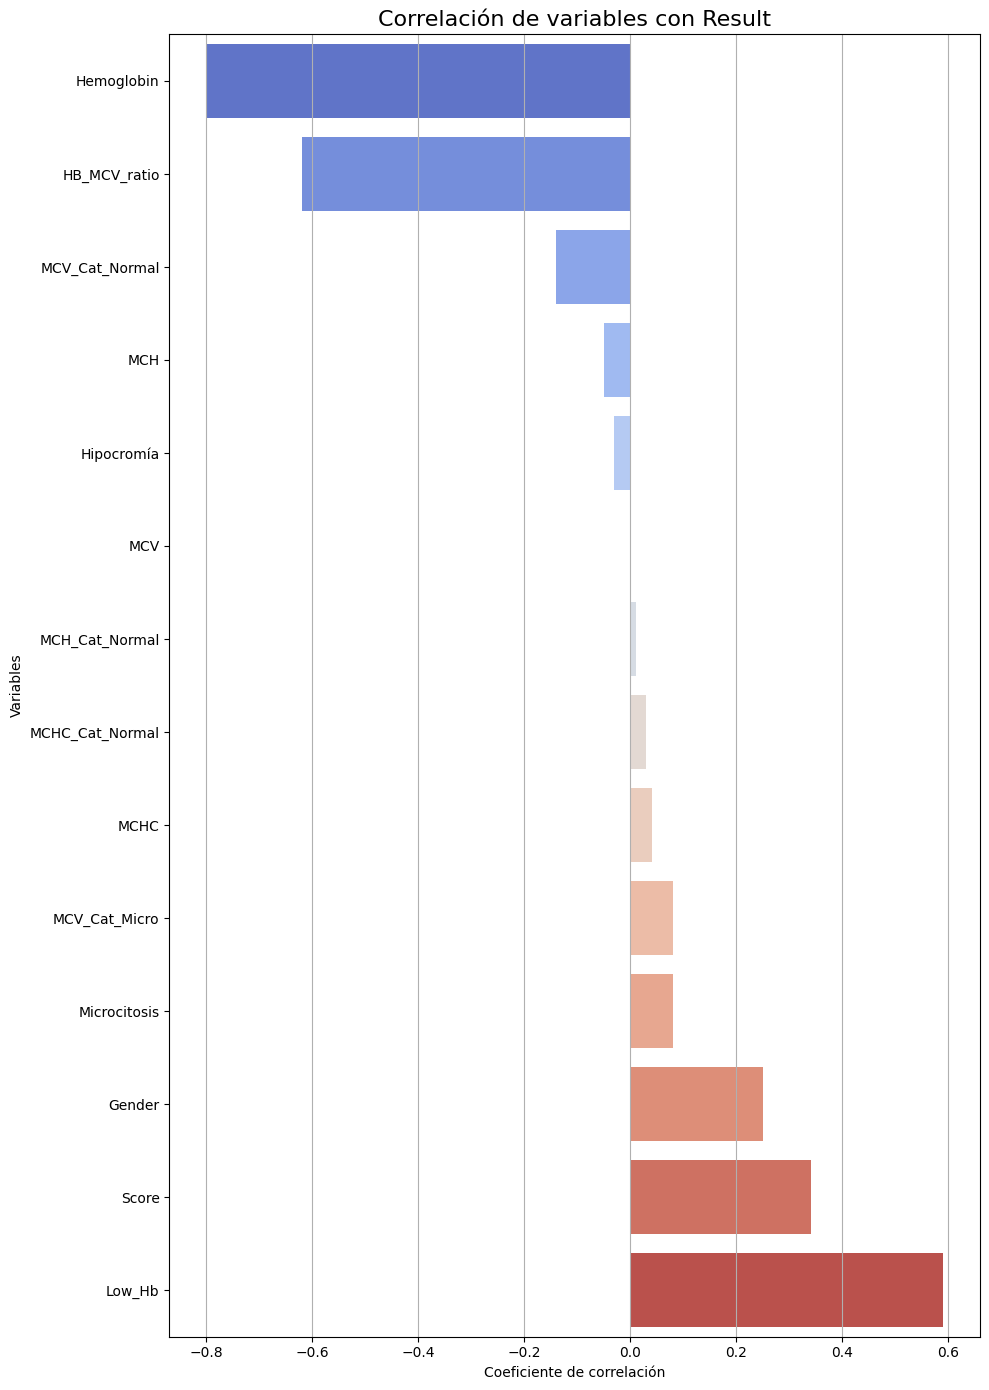

In [45]:
# Visualizando mejor las correlaciones con la variable Churn

corr = corr_df.corr().round(2)

corr = corr.drop(index='Result').sort_values(by='Result', ascending=True)

plt.figure(figsize=(10, 14))
sns.barplot(
    x='Result',
    y=corr.index,
    data=corr,
    palette='coolwarm'
)
plt.title("Correlación de variables con Result", fontsize=16)
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# 7. Observaciones

El analisis de correlacion y multicolinealidad determino que:

* `Hemoglobin` presenta la mayor relación con el diagnostico de Anemia dentro de las variables analizadas, indicando que es una caracteristica relevante para la clasificación

* `Low_Hb`, `HB_MCV_ratio` y `MCV` muestran una relación significativa con la variable objetivo, por lo que podrian aportar capacidad predicitiva al modelo.

* Las features `Hemoglobin`, `HB_MCV_ratio` y `MCV` presentan una alta dependencia entre sí.  Sin embargo, este comportamiento es esperado debido a que corresponden a indicadores hematológicos relacionados con la detección de anemia.

* La feature derivada `HB_MCV_ratio` combina información de `Hemoglobin` y `MCV`, mientras que variables como `MCH` y `MCHC` también están asociadas con estos parámetros, generando una dependencia natural entre las características.

* La multicolinealidad detectada **no implica necesariamente eliminarlas automáticamente estas variables**, sino evaluar su impacto durante el entrenamiento y validación del modelo.

* Las features `MCHC_Cat_Normal`, `MCH_Cat_Normal`, `Hipocromía`, `Microcitosis`, `MCV_Cat_Micro` y `MCV_Cat_Normal` presentan una relación sustancialmente menor con la variable objetivo y ademas muestran redundancia entre ellas.

* Se recomienda evaluar la eliminación de las variables mencionadas antes del modelado, puesto que podrian aumentar la complejidad sin aportar información adicional.

# 8. Eliminando las features

In [46]:
# del df de los datos de entrenamiento, eliminamos las features listadas
X_train_df = X_train_df.drop(columns=['Hipocromía', 'Microcitosis', 'MCV_Cat_Micro',
                       'MCV_Cat_Normal', 'MCHC_Cat_Normal', 'MCH_Cat_Normal'], axis=1)

In [47]:
X_train_df

,Gender,Hemoglobin,MCH,MCHC,MCV,Low_Hb,HB_MCV_ratio,Score
0,-1.063438,-1.387327,-0.884147,-0.733130,0.845910,1.417424,-1.641290,0.783577
1,-1.063438,1.686471,-1.115811,-1.160359,1.083049,-0.705505,0.670016,-0.372577
2,-1.063438,1.232960,0.660285,-1.373974,-1.391448,-0.705505,1.990763,0.783577
3,0.940346,-0.480305,-0.703963,-1.729998,0.381942,-0.705505,-0.650730,-0.372577
4,-1.063438,0.930619,-1.424698,1.403015,0.381942,-0.705505,0.339830,-1.528732
...,...,...,...,...,...,...,...,...
988,0.940346,0.981009,0.428620,-0.946745,-1.226481,-0.705505,1.660576,0.783577
989,0.940346,-0.681865,-1.012849,0.690967,-0.979031,-0.705505,0.009643,0.783577
990,-1.063438,0.930619,-1.167292,0.121328,0.814979,-0.705505,0.009643,-0.372577
991,-1.063438,-1.387327,-0.008969,0.192533,-0.432580,1.417424,-0.980917,0.783577


In [48]:
# X_train toma los valores del df con las columnas eliminadas

X_train = X_train_df.values

In [49]:
X_val_df = pd.DataFrame(X_val, columns=final_cols)

X_test_df = pd.DataFrame(X_test, columns=final_cols)

In [50]:
X_val_df = X_val_df.drop(columns=['Hipocromía', 'Microcitosis', 'MCV_Cat_Micro',
                       'MCV_Cat_Normal', 'MCHC_Cat_Normal', 'MCH_Cat_Normal'], axis=1)

In [51]:
X_test_df = X_test_df.drop(columns=['Hipocromía', 'Microcitosis', 'MCV_Cat_Micro',
                       'MCV_Cat_Normal', 'MCHC_Cat_Normal', 'MCH_Cat_Normal'], axis=1)

In [52]:
X_val = X_val_df.values

In [53]:
X_test = X_test_df.values

# 9. Pipeline de preprocesado

In [54]:
class FeatureSelector(BaseEstimator, TransformerMixin):

    def __init__(self, features_to_drop, column_names):
        self.features_to_drop = features_to_drop
        self.column_names = column_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X will be a numpy array from the preprocessor
        X_df = pd.DataFrame(X, columns=self.column_names)
        return X_df.drop(columns=self.features_to_drop, errors="ignore").values

In [55]:
features_to_drop_cleaned = [
    'Hipocromía', 'Microcitosis', 'MCV_Cat_Micro',
    'MCV_Cat_Normal', 'MCHC_Cat_Normal', 'MCH_Cat_Normal'
]

In [56]:
preprocessing_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selector", FeatureSelector(features_to_drop_cleaned, column_names=final_cols))
])

# 10. Guardando los datos

In [57]:
# guardamos los conjuntos de entrenamiento, validacion y prueba

np.save("X_train.npy", X_train)
np.save("X_val.npy", X_val)
np.save("X_test.npy", X_test)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

# x e y antes de segmentar para validación cruzada

X.to_csv("X_temp.csv", index=False)
np.save("y_temp.npy", y)

# Nombres de las features

np.save("feature_names.npy", X_train_df.columns)

# Preprocesador

joblib.dump(
    preprocessor,
    'preprocessor.pkl'
)

# Pipeline de preprocesado

joblib.dump(
    preprocessing_pipeline,
    'preprocessor_pipeline.pkl'
)

['preprocessor_pipeline.pkl']